<a href="https://colab.research.google.com/github/luluremwu/wikidataupload/blob/main/pictureupload.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# Cell 1：載入 Wikimedia Commons 上傳所需套件
# ==========================================

import os
import re
import json
import time
import hashlib
import mimetypes

import requests
import pandas as pd

from pathlib import Path
from urllib.parse import urlparse

print("✅ Cell 1 執行完成")
print("Wikimedia Commons 上傳環境已準備完成")

✅ Cell 1 執行完成
Wikimedia Commons 上傳環境已準備完成


In [ ]:
# ==========================================
# Cell 2：OAuth 2.0 連接 Wikimedia Commons
# ==========================================

import requests

COMMONS_API = "https://commons.wikimedia.org/w/api.php"

# ==========================================
# OAuth 2.0 Access Token
# ⚠️ 分享 / 繳交程式前請務必刪除
# ==========================================

ACCESS_TOKEN = "your token"


# ==========================================
# 建立 Commons API Session
# ==========================================

HEADERS = {
    "User-Agent": "your oAuthname/1.0",
    "Authorization": f"Bearer {ACCESS_TOKEN}"
}

session = requests.Session()
session.headers.update(HEADERS)


# ==========================================
# 測試 OAuth 登入狀態
# ==========================================

params = {
    "action": "query",
    "meta": "userinfo",
    "uiprop": "rights|groups|blockinfo",
    "format": "json"
}

try:
    response = session.get(
        COMMONS_API,
        params=params,
        timeout=30
    )

    print("HTTP Status:", response.status_code)

    data = response.json()
    userinfo = data.get("query", {}).get("userinfo", {})

    if userinfo.get("id", 0) != 0:

        print("\n✅ OAuth 2.0 驗證成功")
        print("登入帳號：", userinfo.get("name"))
        print("User ID：", userinfo.get("id"))
        print("使用者群組：", ", ".join(userinfo.get("groups", [])))

        if "blockid" in userinfo:
            print("\n⚠️ API 回報封鎖資訊")
            print("Block ID：", userinfo.get("blockid"))
            print("原因：", userinfo.get("blockreason"))
        else:
            print("\n✅ API 沒有回報帳號封鎖")

    else:
        print("\n❌ OAuth 驗證失敗")
        print(data)

except Exception as e:
    print("\n❌ Commons API 連線發生錯誤")
    print(e)

HTTP Status: 200

✅ OAuth 2.0 驗證成功
登入帳號： Kenwu99034
User ID： 14996691
使用者群組： *, user, autoconfirmed

✅ API 沒有回報帳號封鎖


In [ ]:
# ============================================================
# Cell 2.5：Wikimedia Commons 登入 / 權限 / Global Block 檢查
#
# 不會上傳或修改任何 Commons 檔案
# ============================================================

import requests

COMMONS_API = "https://commons.wikimedia.org/w/api.php"

print("=" * 70)
print("Cell 2.5：Wikimedia Commons 上傳環境檢查")
print("=" * 70)


commons_login_ok = False
commons_block_ok = False
commons_upload_ok = False


try:

    # ========================================================
    # 1. 登入與權限檢查
    # ========================================================

    response = session.get(
        COMMONS_API,
        params={
            "action": "query",
            "meta": "userinfo",
            "uiprop": "rights",
            "assert": "user",
            "format": "json"
        },
        timeout=30
    )

    print(f"HTTP Status：{response.status_code}")

    response.raise_for_status()

    result = response.json()

    userinfo = (
        result
        .get("query", {})
        .get("userinfo", {})
    )

    username = userinfo.get("name")
    user_id = userinfo.get("id")
    rights = userinfo.get("rights", [])


    if not username:

        print()
        print("❌ Wikimedia Commons 登入狀態異常")

    else:

        commons_login_ok = True

        print()
        print("✅ Wikimedia Commons 登入狀態正常")

        print()
        print(f"使用者：{username}")
        print(f"User ID：{user_id}")


        # ====================================================
        # 2. 必要權限
        # ====================================================

        print()
        print("必要權限：")

        required_rights = [
            "upload",
            "edit",
            "createpage"
        ]

        missing_rights = []


        for right in required_rights:

            if right in rights:

                print(f"✅ {right}")

            else:

                print(f"❌ {right}")
                missing_rights.append(right)


        if missing_rights:

            commons_login_ok = False


    # ========================================================
    # 3. 查目前 Colab 對外 IP
    # ========================================================

    print()
    print("-" * 70)
    print("正在檢查目前 Colab 對外 IP...")

    ip_response = requests.get(
        "https://api.ipify.org",
        params={
            "format": "json"
        },
        timeout=15
    )

    ip_response.raise_for_status()

    current_ip = (
        ip_response
        .json()
        .get("ip")
    )

    print(f"目前 IP：{current_ip}")


    # ========================================================
    # 4. Wikimedia Global Block 查詢
    # ========================================================

    block_response = session.get(
        COMMONS_API,
        params={
            "action": "query",
            "list": "globalblocks",
            "bgip": current_ip,
            "bgprop": "id|target|by|timestamp|expiry|reason|range",
            "format": "json"
        },
        timeout=30
    )

    block_response.raise_for_status()

    block_data = block_response.json()

    global_blocks = (
        block_data
        .get("query", {})
        .get("globalblocks", [])
    )


    # ========================================================
    # 5. 判斷 Block
    # ========================================================

    print()

    if len(global_blocks) == 0:

        commons_block_ok = True

        print(
            "✅ 目前 IP 未查到 Wikimedia Global Block"
        )

    else:

        commons_block_ok = False

        print(
            "❌ 目前 IP 受到 Wikimedia Global Block"
        )

        print()

        for block in global_blocks:

            print(
                f"封鎖範圍："
                f"{block.get('range') or block.get('target')}"
            )

            print(
                f"原因："
                f"{block.get('reason')}"
            )

            print(
                f"到期時間："
                f"{block.get('expiry')}"
            )

            print(
                f"Block ID："
                f"{block.get('id')}"
            )

            print()


    # ========================================================
    # 6. 最終判斷
    # ========================================================

    commons_upload_ok = (
        commons_login_ok
        and
        commons_block_ok
    )


    print("=" * 70)

    if commons_upload_ok:

        print(
            "✅ 可以進入 Wikimedia Commons 上傳階段"
        )

    else:

        print(
            "❌ 目前不建議執行 Wikimedia Commons 上傳"
        )

        if not commons_login_ok:

            print(
                "原因：登入或必要權限異常"
            )

        if not commons_block_ok:

            print(
                "原因：目前 Colab IP "
                "受到 Wikimedia Global Block"
            )

            print(
                "請重新連線 Colab Runtime "
                "後再次執行 Cell 2.5。"
            )


except Exception as e:

    print()
    print("❌ Cell 2.5 檢查失敗")
    print(f"錯誤：{e}")

    commons_login_ok = False
    commons_block_ok = False
    commons_upload_ok = False

Cell 2.5：Wikimedia Commons 上傳環境檢查
HTTP Status：200

✅ Wikimedia Commons 登入狀態正常

使用者：Kenwu99034
User ID：14996691

必要權限：
✅ upload
✅ edit
✅ createpage

----------------------------------------------------------------------
正在檢查目前 Colab 對外 IP...
目前 IP：34.173.84.230

✅ 目前 IP 未查到 Wikimedia Global Block
✅ 可以進入 Wikimedia Commons 上傳階段


In [ ]:
# ============================================================
# Cell 3：讀取 Wikimedia Commons 上傳資料
#
# 功能：
# 1. 上傳 Excel / CSV
# 2. 自動讀取資料
# 3. 檢查 Commons 上傳所需欄位
# 4. 預先產生未來的 Commons 檔名
#
# 不會修改原始檔案
# 不會上傳圖片至 Commons
# ============================================================

import os
import pandas as pd
from google.colab import files

print("=" * 70)
print("Cell 3：讀取 Wikimedia Commons 上傳資料")
print("=" * 70)


# ============================================================
# 1. 上傳資料檔
# ============================================================

print("請選擇整理好的 Excel / CSV 資料檔：")
print()

uploaded = files.upload()

if not uploaded:
    raise ValueError("❌ 沒有選擇任何資料檔")

data_filename = list(uploaded.keys())[0]

print()
print(f"已選擇資料檔：{data_filename}")


# ============================================================
# 2. 讀取資料
# ============================================================

if data_filename.lower().endswith(".csv"):

    df = pd.read_csv(data_filename)

elif data_filename.lower().endswith(".xlsx"):

    df = pd.read_excel(data_filename)

elif data_filename.lower().endswith(".xls"):

    df = pd.read_excel(data_filename)

else:

    raise ValueError(
        "❌ 不支援的檔案格式，請使用 CSV / XLSX / XLS"
    )


# ============================================================
# 3. 建立原始資料備份
# ============================================================

df_original = df.copy()


# ============================================================
# 4. 檢查必要欄位
# ============================================================

required_columns = [
    "reconcile_title",
    "圖片",
    "描述",
    "url"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

print()
print("-" * 70)
print("必要欄位檢查：")

for column in required_columns:

    if column in df.columns:
        print(f"✅ {column}")
    else:
        print(f"❌ {column}")


if missing_columns:

    raise ValueError(
        "缺少必要欄位："
        + ", ".join(missing_columns)
    )


# ============================================================
# 5. 產生 Commons 預定檔名
# ============================================================

def make_commons_filename(row):

    title = str(row["reconcile_title"]).strip()
    original_filename = str(row["圖片"]).strip()

    # 取得原始圖片副檔名
    _, extension = os.path.splitext(original_filename)

    # 如果沒有副檔名，預設使用 .jpg
    if not extension:
        extension = ".jpg"

    return f"{title}{extension.lower()}"


df["Commons預定檔名"] = df.apply(
    make_commons_filename,
    axis=1
)


# ============================================================
# 6. 顯示基本資訊
# ============================================================

print()
print("-" * 70)

print("✅ 資料讀取成功")
print(f"資料筆數：{len(df)}")
print(f"欄位數量：{len(df.columns)}")


# ============================================================
# 7. 預覽 Commons 上傳資料
# ============================================================

print()
print("-" * 70)
print("Commons 上傳資料預覽：")

preview_columns = [
    "reconcile_title",
    "圖片",
    "Commons預定檔名",
    "描述",
    "url"
]

display(
    df[preview_columns].head(10)
)


print()
print("=" * 70)
print("✅ Cell 3 完成")
print("目前尚未上傳任何圖片")
print("=" * 70)

Cell 3：讀取 Wikimedia Commons 上傳資料
請選擇整理好的 Excel / CSV 資料檔：



Saving 圖片上傳測試多筆.xlsx to 圖片上傳測試多筆.xlsx

已選擇資料檔：圖片上傳測試多筆.xlsx

----------------------------------------------------------------------
必要欄位檢查：
✅ reconcile_title
✅ 圖片
✅ 描述
✅ url

----------------------------------------------------------------------
✅ 資料讀取成功
資料筆數：2
欄位數量：7

----------------------------------------------------------------------
Commons 上傳資料預覽：


,reconcile_title,圖片,Commons預定檔名,描述,url
0,楊大章仿宋院本金陵圖 卷,K2A001732N000000000SDAAA.jpg,楊大章仿宋院本金陵圖 卷.jpg,1.侯怡利，〈江雨霏霏江草齊 六朝如夢鳥空啼 — 清楊大章〈仿宋院本金陵圖〉〉，《故宮文物月...,https://digitalarchive.npm.gov.tw/Collection/D...
1,徽宗真蹟耄耋圖 卷,K2A001419N000000000PAD.jpg,徽宗真蹟耄耋圖 卷.jpg,故宮書畫錄（卷八），第四冊，頁32,https://digitalarchive.npm.gov.tw/Collection/D...



✅ Cell 3 完成
目前尚未上傳任何圖片


In [ ]:
# ============================================================
# Cell 4：上傳圖片檔並與 Excel 資料配對
#
# 功能：
# 1. 一次選擇多張圖片上傳到 Colab
# 2. 依 Excel「圖片」欄尋找對應圖片
# 3. 標記圖片是否成功配對
# 4. 建立後續 Commons 上傳使用的圖片路徑
#
# 不會上傳任何圖片到 Wikimedia Commons
# ============================================================

import os
from google.colab import files

print("=" * 70)
print("Cell 4：上傳圖片檔並與 Excel 資料配對")
print("=" * 70)


# ============================================================
# 1. 建立圖片資料夾
# ============================================================

IMAGE_FOLDER = "/content/commons_images"

os.makedirs(
    IMAGE_FOLDER,
    exist_ok=True
)


# ============================================================
# 2. 選擇並上傳圖片
# ============================================================

print("請選擇要上傳的 JPG / JPEG / PNG 圖片：")
print("可一次選擇多張圖片。")
print()

uploaded_images = files.upload()


if not uploaded_images:

    raise ValueError(
        "❌ 沒有選擇任何圖片"
    )


# ============================================================
# 3. 將圖片存入指定資料夾
# ============================================================

saved_files = []

for filename, file_content in uploaded_images.items():

    file_path = os.path.join(
        IMAGE_FOLDER,
        filename
    )

    with open(file_path, "wb") as f:
        f.write(file_content)

    saved_files.append(filename)


print()
print(f"✅ 已上傳圖片：{len(saved_files)} 張")


# ============================================================
# 4. 建立圖片檔名索引
#
# Windows 對大小寫較不敏感，
# Commons / Linux 環境則要特別注意，
# 因此這裡建立小寫索引方便配對。
# ============================================================

image_index = {
    filename.lower(): filename
    for filename in saved_files
}


# ============================================================
# 5. 配對 Excel「圖片」欄
# ============================================================

def find_image_file(filename):

    # 空值
    if pd.isna(filename):
        return None

    filename = str(filename).strip()

    if not filename:
        return None

    matched_filename = image_index.get(
        filename.lower()
    )

    if not matched_filename:
        return None

    return os.path.join(
        IMAGE_FOLDER,
        matched_filename
    )


df["圖片路徑"] = df["圖片"].apply(
    find_image_file
)


df["圖片配對狀態"] = df["圖片路徑"].apply(
    lambda path:
        "✅ 已找到"
        if path
        else "❌ 找不到"
)


# ============================================================
# 6. 統計配對結果
# ============================================================

matched_count = (
    df["圖片路徑"]
    .notna()
    .sum()
)

missing_count = (
    df["圖片路徑"]
    .isna()
    .sum()
)


print()
print("-" * 70)

print("圖片配對結果：")

print(
    f"✅ 成功配對：{matched_count} 筆"
)

print(
    f"❌ 找不到圖片：{missing_count} 筆"
)


# ============================================================
# 7. 顯示配對預覽
# ============================================================

print()
print("-" * 70)
print("圖片配對預覽：")

preview_columns = [
    "reconcile_title",
    "圖片",
    "Commons預定檔名",
    "圖片配對狀態"
]

display(
    df[preview_columns].head(20)
)


# ============================================================
# 8. 顯示找不到的圖片
# ============================================================

missing_images = df[
    df["圖片路徑"].isna()
]


if len(missing_images) > 0:

    print()
    print("-" * 70)

    print("⚠️ 以下資料找不到對應圖片：")

    display(
        missing_images[
            [
                "reconcile_title",
                "圖片"
            ]
        ]
    )


print()
print("=" * 70)

if missing_count == 0:

    print("✅ Cell 4 完成：所有圖片皆成功配對")

else:

    print(
        f"⚠️ Cell 4 完成："
        f"有 {missing_count} 筆圖片尚未配對"
    )

print("目前尚未上傳任何圖片至 Wikimedia Commons")
print("=" * 70)

Cell 4：上傳圖片檔並與 Excel 資料配對
請選擇要上傳的 JPG / JPEG / PNG 圖片：
可一次選擇多張圖片。



Saving K2A001419N000000000PAD.jpg to K2A001419N000000000PAD.jpg
Saving K2A001732N000000000SDAAA.jpg to K2A001732N000000000SDAAA.jpg

✅ 已上傳圖片：2 張

----------------------------------------------------------------------
圖片配對結果：
✅ 成功配對：2 筆
❌ 找不到圖片：0 筆

----------------------------------------------------------------------
圖片配對預覽：


,reconcile_title,圖片,Commons預定檔名,圖片配對狀態
0,楊大章仿宋院本金陵圖 卷,K2A001732N000000000SDAAA.jpg,楊大章仿宋院本金陵圖 卷.jpg,✅ 已找到
1,徽宗真蹟耄耋圖 卷,K2A001419N000000000PAD.jpg,徽宗真蹟耄耋圖 卷.jpg,✅ 已找到



✅ Cell 4 完成：所有圖片皆成功配對
目前尚未上傳任何圖片至 Wikimedia Commons


In [ ]:
# ============================================================
# Cell 5：Wikimedia Commons 重複圖片檢查
#
# 功能：
# 1. 計算每張本機圖片的 SHA1
# 2. 用 SHA1 查詢 Wikimedia Commons
# 3. 已存在：取得 Commons 既有檔名，不再上傳
# 4. 不存在：標記為待上傳
#
# 不會上傳或修改任何 Commons 檔案
# ============================================================

import hashlib
import os
import pandas as pd

print("=" * 70)
print("Cell 5：Wikimedia Commons 重複圖片檢查")
print("=" * 70)


# ============================================================
# 1. 計算本機檔案 SHA1
# ============================================================

def calculate_sha1(file_path):

    if not file_path or not os.path.exists(file_path):
        return None

    sha1 = hashlib.sha1()

    with open(file_path, "rb") as f:

        while True:
            chunk = f.read(1024 * 1024)

            if not chunk:
                break

            sha1.update(chunk)

    return sha1.hexdigest()


print("正在計算本機圖片 SHA1...")

df["圖片SHA1"] = df["圖片路徑"].apply(
    calculate_sha1
)


# ============================================================
# 2. 用 SHA1 查詢 Commons
# ============================================================

def check_commons_duplicate(sha1_value):

    if not sha1_value:
        return {
            "status": "❌ 無圖片",
            "existing_filename": None
        }

    params = {
        "action": "query",
        "list": "allimages",
        "aisha1": sha1_value,
        "ailimit": 5,
        "format": "json"
    }

    try:

        response = session.get(
            COMMONS_API,
            params=params,
            timeout=30
        )

        response.raise_for_status()

        data = response.json()

        images = (
            data
            .get("query", {})
            .get("allimages", [])
        )

        if images:

            existing_name = images[0].get("name")

            return {
                "status": "⚠️ Commons 已存在",
                "existing_filename": existing_name
            }

        else:

            return {
                "status": "✅ 未重複",
                "existing_filename": None
            }

    except Exception as e:

        return {
            "status": f"❌ 查詢失敗：{e}",
            "existing_filename": None
        }


# ============================================================
# 3. 逐筆查詢
# ============================================================

print()
print("正在查詢 Wikimedia Commons 是否已有相同圖片...")

duplicate_results = []

for index, row in df.iterrows():

    title = row.get("reconcile_title")
    sha1_value = row.get("圖片SHA1")

    print(
        f"[{index + 1}/{len(df)}] "
        f"{title}"
    )

    result = check_commons_duplicate(
        sha1_value
    )

    duplicate_results.append(result)


# ============================================================
# 4. 將結果寫回 DataFrame
# ============================================================

df["Commons重複狀態"] = [
    result["status"]
    for result in duplicate_results
]

df["Commons既有檔名"] = [
    result["existing_filename"]
    for result in duplicate_results
]


# ============================================================
# 5. 決定是否進入上傳流程
# ============================================================

def determine_upload_status(row):

    if row["Commons重複狀態"] == "✅ 未重複":
        return True

    return False


df["待上傳"] = df.apply(
    determine_upload_status,
    axis=1
)


# ============================================================
# 6. 產生最後要給 Wikidata P18 的檔名
#
# 已存在 → 使用 Commons 既有檔名
# 未存在 → 使用預定的新 Commons 檔名
# ============================================================

def determine_final_filename(row):

    if row["Commons既有檔名"]:
        return row["Commons既有檔名"]

    if row["待上傳"]:
        return row["Commons預定檔名"]

    return None


df["Commons最終檔名"] = df.apply(
    determine_final_filename,
    axis=1
)


# ============================================================
# 7. 統計結果
# ============================================================

duplicate_count = (
    df["Commons既有檔名"]
    .notna()
    .sum()
)

upload_count = (
    df["待上傳"]
    .sum()
)

error_count = len(df) - duplicate_count - upload_count


print()
print("-" * 70)
print("Commons 重複檢查結果：")

print(
    f"⚠️ Commons 已存在：{duplicate_count} 筆"
)

print(
    f"✅ 待上傳：{upload_count} 筆"
)

print(
    f"❌ 無法進入上傳流程：{error_count} 筆"
)


# ============================================================
# 8. 顯示結果
# ============================================================

print()
print("-" * 70)
print("重複檢查預覽：")

preview_columns = [
    "reconcile_title",
    "圖片",
    "Commons預定檔名",
    "Commons重複狀態",
    "Commons既有檔名",
    "待上傳",
    "Commons最終檔名"
]

display(
    df[preview_columns]
)


# ============================================================
# 9. 建立待上傳資料
# ============================================================

df_upload = df[
    df["待上傳"] == True
].copy()


print()
print("=" * 70)
print(
    f"✅ Cell 5 完成，目前共有 {len(df_upload)} 筆進入後續上傳流程"
)
print("目前尚未上傳任何圖片至 Wikimedia Commons")
print("=" * 70)

Cell 5：Wikimedia Commons 重複圖片檢查
正在計算本機圖片 SHA1...

正在查詢 Wikimedia Commons 是否已有相同圖片...
[1/2] 楊大章仿宋院本金陵圖　卷
[2/2] 徽宗真蹟耄耋圖　卷

----------------------------------------------------------------------
Commons 重複檢查結果：
⚠️ Commons 已存在：0 筆
✅ 待上傳：2 筆
❌ 無法進入上傳流程：0 筆

----------------------------------------------------------------------
重複檢查預覽：


,reconcile_title,圖片,Commons預定檔名,Commons重複狀態,Commons既有檔名,待上傳,Commons最終檔名
0,楊大章仿宋院本金陵圖 卷,K2A001732N000000000SDAAA.jpg,楊大章仿宋院本金陵圖 卷.jpg,✅ 未重複,None,True,楊大章仿宋院本金陵圖 卷.jpg
1,徽宗真蹟耄耋圖 卷,K2A001419N000000000PAD.jpg,徽宗真蹟耄耋圖 卷.jpg,✅ 未重複,None,True,徽宗真蹟耄耋圖 卷.jpg



✅ Cell 5 完成，目前共有 2 筆進入後續上傳流程
目前尚未上傳任何圖片至 Wikimedia Commons


In [ ]:
# ============================================================
# Cell 6：產生 Wikimedia Commons 上傳 Metadata
#
# 功能：
# 1. 產生 Commons File page 使用的 {{Information}}
# 2. 自動帶入 Description / Source / Author
# 3. 加入 CC0 授權模板
# 4. 建立後續 Upload API 直接使用的 wikitext
#
# 不會上傳或修改任何 Commons 檔案
# ============================================================

import pandas as pd
from datetime import datetime
from zoneinfo import ZoneInfo

print("=" * 70)
print("Cell 6：產生 Wikimedia Commons 上傳 Metadata")
print("=" * 70)


# ============================================================
# 1. 固定設定
# ============================================================

COMMONS_AUTHOR = "國立故宮博物院"
COMMONS_LICENSE = "{{CC0}}"
# 本次上傳日期（台灣時間）
UPLOAD_DATE = datetime.now(
    ZoneInfo("Asia/Taipei")
).strftime("%Y-%m-%d")

print(f"本次建立日期：{UPLOAD_DATE}")

# ============================================================
# 2. 清理文字
# ============================================================

def clean_text(value):

    if pd.isna(value):
        return ""

    return str(value).strip()


# ============================================================
# 3. 產生 Commons File page wikitext
# ============================================================

def build_commons_wikitext(row):

    description = clean_text(
        row.get("描述")
    )

    source_url = clean_text(
        row.get("url")
    )

    date_value = UPLOAD_DATE


    wikitext = f"""=={{{{int:filedesc}}}}==
{{{{Information
|description={description}
|date={date_value}
|source={source_url}
|author={COMMONS_AUTHOR}
|permission={COMMONS_LICENSE}
|other versions=
}}}}

=={{{{int:license-header}}}}==
{COMMONS_LICENSE}
"""

    return wikitext.strip()


# ============================================================
# 4. 只對待上傳資料建立 Metadata
# ============================================================

df_upload["Commons描述頁"] = df_upload.apply(
    build_commons_wikitext,
    axis=1
)


# ============================================================
# 5. 建立上傳摘要
# ============================================================

def build_upload_comment(row):

    title = clean_text(
        row.get("reconcile_title")
    )

    return (
        f"Uploading {title} "
        f"來源：國立故宮博物院"
    )


df_upload["Commons上傳摘要"] = df_upload.apply(
    build_upload_comment,
    axis=1
)


# ============================================================
# 6. 顯示資料筆數
# ============================================================

print()
print(f"待上傳圖片：{len(df_upload)} 筆")


# ============================================================
# 7. 預覽第一筆 Metadata
# ============================================================

if len(df_upload) > 0:

    first_row = df_upload.iloc[0]

    print()
    print("-" * 70)
    print("第一筆預覽")
    print("-" * 70)

    print()
    print("Commons 檔名：")
    print(
        first_row["Commons預定檔名"]
    )

    print()
    print("上傳摘要：")
    print(
        first_row["Commons上傳摘要"]
    )

    print()
    print("Commons File page：")
    print()

    print(
        first_row["Commons描述頁"]
    )

else:

    print()
    print("⚠️ 沒有待上傳圖片")


print()
print("=" * 70)
print("✅ Cell 6 完成")
print("目前尚未上傳任何圖片至 Wikimedia Commons")
print("=" * 70)

Cell 6：產生 Wikimedia Commons 上傳 Metadata
本次建立日期：2026-08-17

待上傳圖片：2 筆

----------------------------------------------------------------------
第一筆預覽
----------------------------------------------------------------------

Commons 檔名：
楊大章仿宋院本金陵圖　卷.jpg

上傳摘要：
Uploading 楊大章仿宋院本金陵圖　卷 來源：國立故宮博物院

Commons File page：

=={{int:filedesc}}==
{{Information
|description=1.侯怡利，〈江雨霏霏江草齊 六朝如夢鳥空啼 — 清楊大章〈仿宋院本金陵圖〉〉，《故宮文物月刊》，第322期（2010年01月），頁100-106。
|date=2026-08-17
|source=https://digitalarchive.npm.gov.tw/Collection/Detail/5726?dep=P
|author=國立故宮博物院
|permission={{CC0}}
|other versions=
}}

=={{int:license-header}}==
{{CC0}}

✅ Cell 6 完成
目前尚未上傳任何圖片至 Wikimedia Commons


Cell 7：Wikimedia Commons 最終上傳預覽

待上傳圖片總數：2 筆

----------------------------------------------------------------------
Structured Data 繁中說明檢查：
✅ 可寫入：2 筆
❌ 有問題：0 筆

[1/2] 楊大章仿宋院本金陵圖　卷

【圖片】


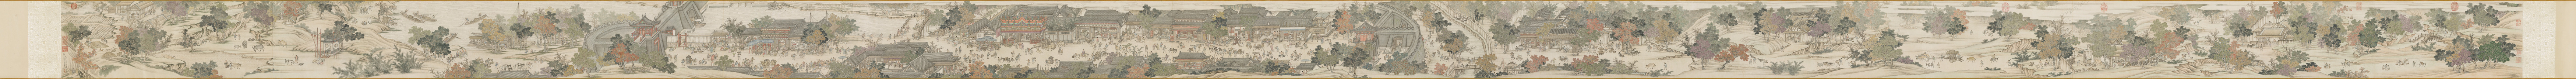


【原始圖片檔名】
K2A001732N000000000SDAAA.jpg

【Commons 上傳檔名】
楊大章仿宋院本金陵圖　卷.jpg

【Commons 描述】
1.侯怡利，〈江雨霏霏江草齊 六朝如夢鳥空啼 — 清楊大章〈仿宋院本金陵圖〉〉，《故宮文物月刊》，第322期（2010年01月），頁100-106。

【中文（繁體）說明 / Structured Data】
1.侯怡利，〈江雨霏霏江草齊 六朝如夢鳥空啼 — 清楊大章〈仿宋院本金陵圖〉〉，《故宮文物月刊》，第322期（2010年01月），頁100-106。
字數：74
狀態： ✅ 可寫入

【來源網址】
https://digitalarchive.npm.gov.tw/Collection/Detail/5726?dep=P

【建立日期】
2026-08-17

【作者】
國立故宮博物院

【授權】
CC0

【上傳摘要】
Uploading 楊大章仿宋院本金陵圖　卷 來源：國立故宮博物院

[2/2] 徽宗真蹟耄耋圖　卷

【圖片】


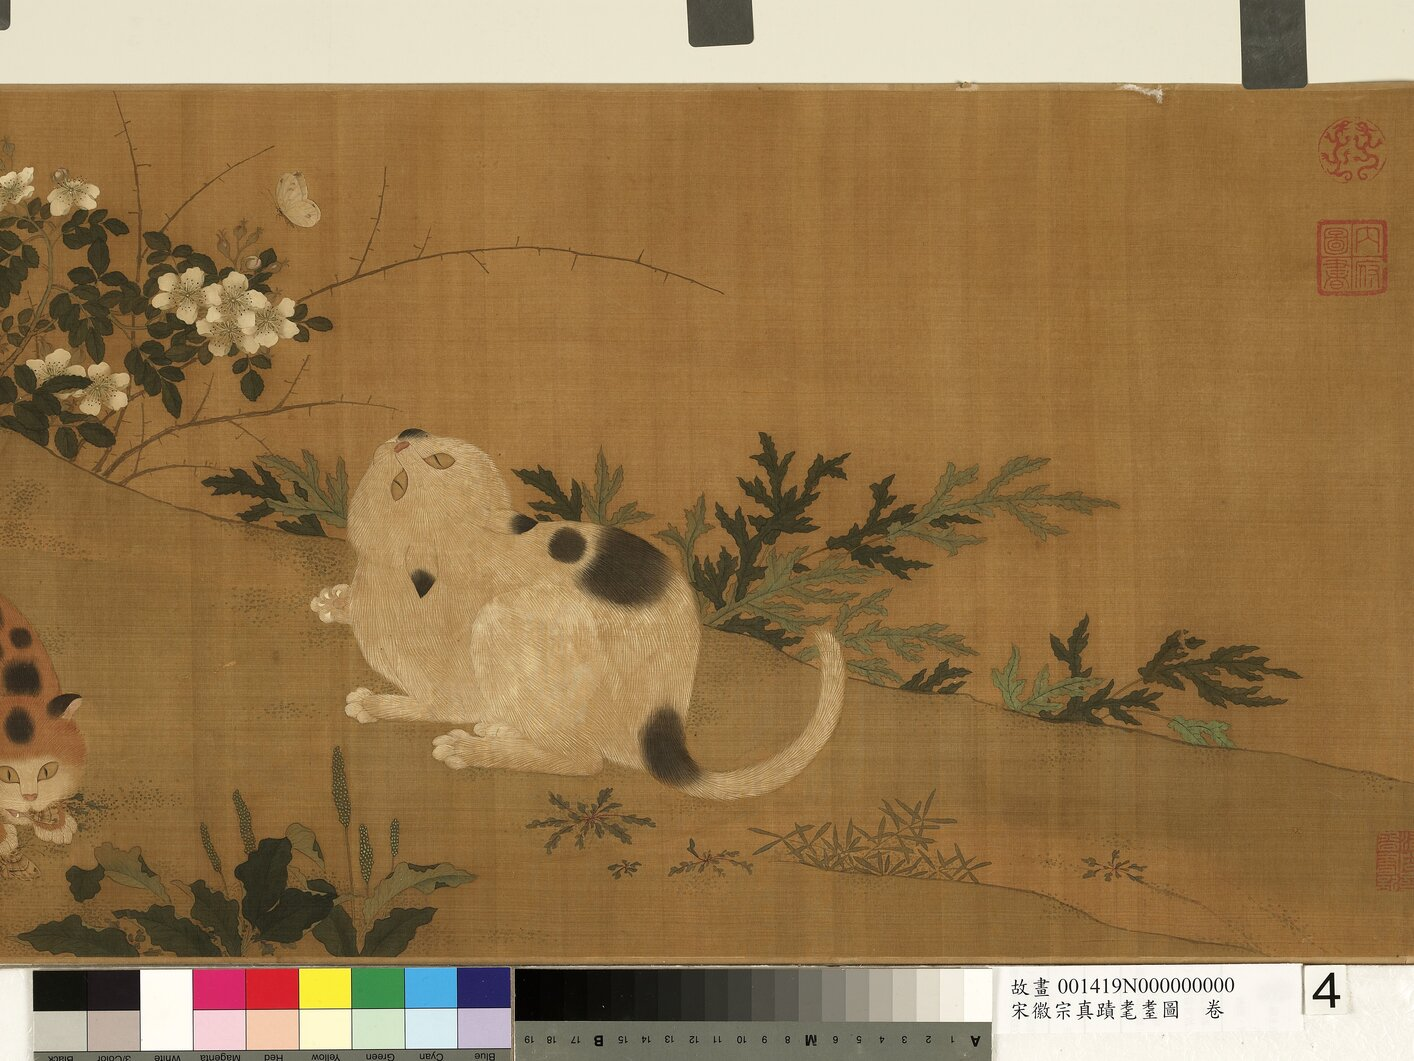


【原始圖片檔名】
K2A001419N000000000PAD.jpg

【Commons 上傳檔名】
徽宗真蹟耄耋圖　卷.jpg

【Commons 描述】
故宮書畫錄（卷八），第四冊，頁32

【中文（繁體）說明 / Structured Data】
故宮書畫錄（卷八），第四冊，頁32
字數：17
狀態： ✅ 可寫入

【來源網址】
https://digitalarchive.npm.gov.tw/Collection/Detail/14092?dep=P

【建立日期】
2026-08-17

【作者】
國立故宮博物院

【授權】
CC0

【上傳摘要】
Uploading 徽宗真蹟耄耋圖　卷 來源：國立故宮博物院

最終上傳摘要

待上傳圖片：2 張
作者：國立故宮博物院
建立日期：2026-08-17
授權：CC0

Structured Data 說明可寫入：2 筆
Structured Data 說明異常：0 筆

✅ 所有資料皆通過上傳前檢查。
請人工確認以上內容。



Output()

In [ ]:
# ============================================================
# Cell 7：Wikimedia Commons 最終上傳預覽 / 人工確認
#
# 功能：
# 1. 顯示所有待上傳圖片
# 2. 檢查檔名、描述、來源、日期、作者、授權
# 3. 將 Excel「描述」同時作為 Commons 繁中說明
# 4. 檢查繁中說明是否可寫入 Structured Data
# 5. 人工確認後才允許 Cell 8 執行
#
# 本 Cell 不會上傳任何圖片
# ============================================================

import os
import re
import pandas as pd
from IPython.display import display, Image
import ipywidgets as widgets

print("=" * 70)
print("Cell 7：Wikimedia Commons 最終上傳預覽")
print("=" * 70)


# ============================================================
# 1. 初始化確認狀態
# ============================================================

commons_final_confirmed = False


# ============================================================
# 2. 基本資料檢查
# ============================================================

if "df_upload" not in globals():

    raise ValueError(
        "❌ 找不到 df_upload，請先執行 Cell 5。"
    )


if len(df_upload) == 0:

    print()
    print("⚠️ 目前沒有需要上傳至 Commons 的圖片。")


else:

    print()
    print(
        f"待上傳圖片總數：{len(df_upload)} 筆"
    )


    # ========================================================
    # 3. 建立 Commons Structured Data 繁中說明
    #
    # 直接使用 Excel「描述」欄
    # ========================================================

    def prepare_commons_caption(value):

        if pd.isna(value):
            return ""

        caption = str(value).strip()

        # 將換行、多餘空白整理成單一空格
        caption = re.sub(
            r"\s+",
            " ",
            caption
        )

        return caption


    df_upload["Commons繁中說明"] = (
        df_upload["描述"]
        .apply(prepare_commons_caption)
    )


    # ========================================================
    # 4. Caption 字數檢查
    # ========================================================

    df_upload["Commons繁中說明字數"] = (
        df_upload["Commons繁中說明"]
        .str.len()
    )


    def check_caption(row):

        caption = row[
            "Commons繁中說明"
        ]

        length = row[
            "Commons繁中說明字數"
        ]

        if not caption:

            return "❌ 說明為空"

        if length > 250:

            return "❌ 超過 250 字元"

        return "✅ 可寫入"


    df_upload["Commons繁中說明狀態"] = (
        df_upload.apply(
            check_caption,
            axis=1
        )
    )


    # ========================================================
    # 5. 統計 Caption
    # ========================================================

    caption_valid_count = (
        df_upload[
            "Commons繁中說明狀態"
        ]
        .eq("✅ 可寫入")
        .sum()
    )

    caption_invalid_count = (
        len(df_upload)
        -
        caption_valid_count
    )


    print()
    print("-" * 70)

    print("Structured Data 繁中說明檢查：")

    print(
        f"✅ 可寫入：{caption_valid_count} 筆"
    )

    print(
        f"❌ 有問題：{caption_invalid_count} 筆"
    )


    # ========================================================
    # 6. 逐筆最終預覽
    # ========================================================

    for number, (index, row) in enumerate(
        df_upload.iterrows(),
        start=1
    ):

        print()
        print("=" * 70)

        print(
            f"[{number}/{len(df_upload)}] "
            f"{row.get('reconcile_title', '')}"
        )

        print("=" * 70)


        # ----------------------------------------------------
        # 圖片
        # ----------------------------------------------------

        print()
        print("【圖片】")

        image_path = row.get(
            "圖片路徑"
        )

        if (
            image_path
            and
            os.path.exists(image_path)
        ):

            display(
                Image(
                    filename=image_path,
                    width=350
                )
            )

        else:

            print(
                "❌ 找不到圖片檔案"
            )


        # ----------------------------------------------------
        # 檔名
        # ----------------------------------------------------

        print()
        print("【原始圖片檔名】")

        print(
            row.get(
                "圖片",
                ""
            )
        )


        print()
        print("【Commons 上傳檔名】")

        print(
            row.get(
                "Commons預定檔名",
                ""
            )
        )


        # ----------------------------------------------------
        # Information Description
        # ----------------------------------------------------

        print()
        print("【Commons 描述】")

        print(
            row.get(
                "描述",
                ""
            )
        )


        # ----------------------------------------------------
        # Structured Data Caption
        # ----------------------------------------------------

        print()
        print(
            "【中文（繁體）說明 / Structured Data】"
        )

        print(
            row.get(
                "Commons繁中說明",
                ""
            )
        )

        print(
            f"字數："
            f"{row.get('Commons繁中說明字數', 0)}"
        )

        print(
            "狀態：",
            row.get(
                "Commons繁中說明狀態",
                ""
            )
        )


        # ----------------------------------------------------
        # Source
        # ----------------------------------------------------

        print()
        print("【來源網址】")

        print(
            row.get(
                "url",
                ""
            )
        )


        # ----------------------------------------------------
        # Metadata
        # ----------------------------------------------------

        print()
        print("【建立日期】")
        print(UPLOAD_DATE)

        print()
        print("【作者】")
        print(COMMONS_AUTHOR)

        print()
        print("【授權】")
        print("CC0")


        # ----------------------------------------------------
        # Upload Summary
        # ----------------------------------------------------

        print()
        print("【上傳摘要】")

        print(
            row.get(
                "Commons上傳摘要",
                ""
            )
        )


    # ========================================================
    # 7. 最終摘要
    # ========================================================

    print()
    print("=" * 70)
    print("最終上傳摘要")
    print("=" * 70)

    print()
    print(
        f"待上傳圖片：{len(df_upload)} 張"
    )

    print(
        f"作者：{COMMONS_AUTHOR}"
    )

    print(
        f"建立日期：{UPLOAD_DATE}"
    )

    print(
        "授權：CC0"
    )

    print()

    print(
        f"Structured Data 說明可寫入："
        f"{caption_valid_count} 筆"
    )

    print(
        f"Structured Data 說明異常："
        f"{caption_invalid_count} 筆"
    )


    # ========================================================
    # 8. 是否允許人工確認
    # ========================================================

    if caption_invalid_count > 0:

        print()
        print(
            "❌ 目前有 Structured Data 說明未通過檢查。"
        )

        print(
            "請先修正資料，再重新執行 Cell 7。"
        )

        commons_final_confirmed = False


    else:

        print()
        print(
            "✅ 所有資料皆通過上傳前檢查。"
        )

        print(
            "請人工確認以上內容。"
        )


        # ====================================================
        # 9. 人工確認按鈕
        # ====================================================

        confirm_button = widgets.Button(
            description="確認，可以進入上傳階段",
            button_style="success",
            icon="check"
        )

        cancel_button = widgets.Button(
            description="取消",
            button_style="danger",
            icon="times"
        )

        confirmation_output = (
            widgets.Output()
        )


        def confirm_upload(button):

            global commons_final_confirmed

            commons_final_confirmed = True

            with confirmation_output:

                confirmation_output.clear_output()

                print()
                print(
                    "✅ 已完成最終人工確認"
                )

                print(
                    "可以進入 Cell 8：Commons 批量上傳"
                )


        def cancel_upload(button):

            global commons_final_confirmed

            commons_final_confirmed = False

            with confirmation_output:

                confirmation_output.clear_output()

                print()
                print(
                    "❌ 已取消上傳確認"
                )

                print(
                    "Cell 8 將不允許執行上傳。"
                )


        confirm_button.on_click(
            confirm_upload
        )

        cancel_button.on_click(
            cancel_upload
        )


        print()

        display(
            widgets.HBox(
                [
                    confirm_button,
                    cancel_button
                ]
            )
        )

        display(
            confirmation_output
        )

In [ ]:
# ============================================================
# Cell 8：Wikimedia Commons 批量上傳
#
# ⚠️ 本 Cell 會真正寫入 Wikimedia Commons
#
# 功能：
# 1. 檢查 Cell 7 人工確認
# 2. 檢查 Commons 上傳環境
# 3. 逐筆上傳圖片
# 4. 上傳成功後取得 File page ID
# 5. 寫入 Structured Data 中文（繁體）說明 zh-tw
# 6. 單筆失敗不影響後續資料
# 7. 成功結果寫回 df / df_upload
# ============================================================

import os
import time
import pandas as pd

print("=" * 70)
print("Cell 8：Wikimedia Commons 批量圖片上傳")
print("=" * 70)


# ============================================================
# 1. 安全檢查
# ============================================================

if "commons_final_confirmed" not in globals():
    raise RuntimeError(
        "❌ 找不到 Cell 7 的人工確認狀態，請先執行 Cell 7。"
    )

if not commons_final_confirmed:
    raise RuntimeError(
        "❌ 尚未完成 Cell 7 人工確認，禁止上傳。"
    )

if "commons_upload_ok" not in globals():
    raise RuntimeError(
        "❌ 找不到 Commons 環境檢查結果，請先執行 Cell 2.5。"
    )

if not commons_upload_ok:
    raise RuntimeError(
        "❌ Commons 上傳環境未通過檢查，禁止上傳。"
    )

if "df_upload" not in globals() or len(df_upload) == 0:
    raise RuntimeError(
        "❌ 目前沒有待上傳資料。"
    )

if "Commons繁中說明" not in df_upload.columns:
    raise RuntimeError(
        "❌ 找不到 Commons繁中說明，請先重新執行新版 Cell 7。"
    )


print("✅ Cell 7 人工確認：通過")
print("✅ Commons 上傳環境：通過")
print(f"✅ 待處理資料：{len(df_upload)} 筆")


# ============================================================
# 2. 建立結果欄位
# ============================================================

result_columns = [
    "Commons上傳狀態",
    "Commons最終檔名",
    "Commons繁中說明寫入狀態",
    "Commons MediaInfo ID",
    "Commons上傳訊息"
]

for column in result_columns:

    if column not in df_upload.columns:
        df_upload[column] = None

    if column not in df.columns:
        df[column] = None


# ============================================================
# 3. 取得 CSRF Token
# ============================================================

print()
print("正在取得 CSRF Token...")

token_response = session.get(
    COMMONS_API,
    params={
        "action": "query",
        "meta": "tokens",
        "type": "csrf",
        "format": "json"
    },
    timeout=30
)

token_response.raise_for_status()

csrf_token = (
    token_response.json()
    .get("query", {})
    .get("tokens", {})
    .get("csrftoken")
)

if not csrf_token:
    raise RuntimeError(
        "❌ 無法取得 CSRF Token"
    )

print("✅ CSRF Token 取得成功")


# ============================================================
# 4. 查 File page ID
# ============================================================

def get_file_page_id(filename):

    response = session.get(
        COMMONS_API,
        params={
            "action": "query",
            "titles": f"File:{filename}",
            "format": "json"
        },
        timeout=30
    )

    response.raise_for_status()

    pages = (
        response.json()
        .get("query", {})
        .get("pages", {})
    )

    page = next(
        iter(pages.values()),
        {}
    )

    if "missing" in page:
        return None

    return page.get("pageid")


# ============================================================
# 5. 寫入 Commons Structured Data Caption
# ============================================================

def set_zh_tw_caption(media_info_id, caption):

    response = session.post(
        COMMONS_API,
        data={
            "action": "wbsetlabel",
            "id": media_info_id,
            "language": "zh-tw",
            "value": caption,
            "token": csrf_token,
            "format": "json"
        },
        timeout=30
    )

    response.raise_for_status()

    result = response.json()

    if "error" in result:

        error = result["error"]

        return (
            False,
            f"{error.get('code')}: "
            f"{error.get('info')}"
        )

    if result.get("success") == 1:

        return (
            True,
            "繁體中文說明寫入成功"
        )

    return (
        False,
        str(result)
    )


# ============================================================
# 6. 統計
# ============================================================

success_count = 0
partial_count = 0
warning_count = 0
failed_count = 0
skipped_count = 0

total_count = len(df_upload)


# ============================================================
# 7. 開始逐筆處理
# ============================================================

print()
print("=" * 70)
print("開始 Wikimedia Commons 批量上傳")
print("=" * 70)


for number, (index, row) in enumerate(
    df_upload.iterrows(),
    start=1
):

    print()
    print("-" * 70)

    print(
        f"[{number}/{total_count}] "
        f"{row.get('reconcile_title', '')}"
    )

    print("-" * 70)


    # ========================================================
    # A. 已完整成功 → 跳過
    # ========================================================

    previous_upload_status = row.get(
        "Commons上傳狀態"
    )

    previous_caption_status = row.get(
        "Commons繁中說明寫入狀態"
    )

    if (
        previous_upload_status == "✅ 上傳成功"
        and
        previous_caption_status == "✅ 寫入成功"
    ):

        print(
            "⏭️ 此筆先前已完整處理，跳過。"
        )

        print(
            "Commons 檔名：",
            row.get("Commons最終檔名")
        )

        skipped_count += 1
        continue


    # ========================================================
    # B. 取得資料
    # ========================================================

    image_path = row.get(
        "圖片路徑"
    )

    commons_filename = row.get(
        "Commons預定檔名"
    )

    description_text = row.get(
        "Commons描述頁"
    )

    upload_comment = row.get(
        "Commons上傳摘要"
    )

    caption_text = row.get(
        "Commons繁中說明"
    )


    # ========================================================
    # C. 基本檢查
    # ========================================================

    if (
        not image_path
        or
        not os.path.exists(image_path)
    ):

        message = (
            f"找不到圖片檔案：{image_path}"
        )

        print(f"❌ {message}")

        df_upload.loc[
            index,
            "Commons上傳狀態"
        ] = "❌ 上傳失敗"

        df.loc[
            index,
            "Commons上傳狀態"
        ] = "❌ 上傳失敗"

        df_upload.loc[
            index,
            "Commons上傳訊息"
        ] = message

        df.loc[
            index,
            "Commons上傳訊息"
        ] = message

        failed_count += 1
        continue


    if (
        pd.isna(commons_filename)
        or
        not str(commons_filename).strip()
    ):

        message = "Commons 預定檔名為空"

        print(f"❌ {message}")

        df_upload.loc[
            index,
            "Commons上傳狀態"
        ] = "❌ 上傳失敗"

        df.loc[
            index,
            "Commons上傳狀態"
        ] = "❌ 上傳失敗"

        failed_count += 1
        continue


    # ========================================================
    # D. 如果圖片之前已成功上傳
    #
    # 例如你剛才單筆測試成功的第一張，
    # 就不要再次上傳，只補 Caption。
    # ========================================================

    uploaded_filename = row.get(
        "Commons最終檔名"
    )

    image_already_uploaded = (
        previous_upload_status
        == "✅ 上傳成功"
        and
        pd.notna(uploaded_filename)
        and
        str(uploaded_filename).strip()
    )


    # ========================================================
    # E. 尚未上傳 → Upload API
    # ========================================================

    if not image_already_uploaded:

        print(
            "原始圖片：",
            row.get("圖片")
        )

        print(
            "Commons 檔名：",
            commons_filename
        )

        print(
            "正在上傳圖片..."
        )


        upload_params = {

            "action": "upload",

            "filename": commons_filename,

            "text": description_text,

            "comment": upload_comment,

            "token": csrf_token,

            # 不自動忽略 Commons Warning
            "ignorewarnings": 0,

            "format": "json"
        }


        try:

            with open(
                image_path,
                "rb"
            ) as image_file:

                upload_files = {
                    "file": (
                        os.path.basename(
                            image_path
                        ),
                        image_file
                    )
                }

                upload_response = (
                    session.post(
                        COMMONS_API,
                        data=upload_params,
                        files=upload_files,
                        timeout=120
                    )
                )


            upload_response.raise_for_status()

            upload_result = (
                upload_response.json()
            )


            # =================================================
            # API Error
            # =================================================

            if "error" in upload_result:

                error = (
                    upload_result["error"]
                )

                message = (
                    f"{error.get('code')}: "
                    f"{error.get('info')}"
                )

                print(
                    "❌ Commons API 上傳失敗"
                )

                print(
                    message
                )

                df_upload.loc[
                    index,
                    "Commons上傳狀態"
                ] = "❌ 上傳失敗"

                df.loc[
                    index,
                    "Commons上傳狀態"
                ] = "❌ 上傳失敗"

                df_upload.loc[
                    index,
                    "Commons上傳訊息"
                ] = message

                df.loc[
                    index,
                    "Commons上傳訊息"
                ] = message

                failed_count += 1
                continue


            # =================================================
            # Upload Warning
            # =================================================

            if (
                upload_result
                .get("upload", {})
                .get("result")
                == "Warning"
            ):

                warnings = (
                    upload_result
                    .get("upload", {})
                    .get("warnings", {})
                )

                message = str(
                    warnings
                )

                print(
                    "⚠️ Commons Upload Warning"
                )

                print(
                    message
                )

                print(
                    "本筆未強制上傳，繼續下一筆。"
                )

                df_upload.loc[
                    index,
                    "Commons上傳狀態"
                ] = "⚠️ Upload Warning"

                df.loc[
                    index,
                    "Commons上傳狀態"
                ] = "⚠️ Upload Warning"

                df_upload.loc[
                    index,
                    "Commons上傳訊息"
                ] = message

                df.loc[
                    index,
                    "Commons上傳訊息"
                ] = message

                warning_count += 1
                continue


            # =================================================
            # Upload Success
            # =================================================

            if (
                upload_result
                .get("upload", {})
                .get("result")
                == "Success"
            ):

                uploaded_filename = (
                    upload_result[
                        "upload"
                    ]
                    .get("filename")
                )

                print(
                    "✅ 圖片上傳成功"
                )

                print(
                    "Commons 檔名：",
                    uploaded_filename
                )

                df_upload.loc[
                    index,
                    "Commons上傳狀態"
                ] = "✅ 上傳成功"

                df.loc[
                    index,
                    "Commons上傳狀態"
                ] = "✅ 上傳成功"


                df_upload.loc[
                    index,
                    "Commons最終檔名"
                ] = uploaded_filename

                df.loc[
                    index,
                    "Commons最終檔名"
                ] = uploaded_filename


            else:

                message = str(
                    upload_result
                )

                print(
                    "⚠️ 未預期的 Upload API 回應"
                )

                print(message)

                df_upload.loc[
                    index,
                    "Commons上傳狀態"
                ] = "⚠️ 未預期結果"

                df.loc[
                    index,
                    "Commons上傳狀態"
                ] = "⚠️ 未預期結果"

                warning_count += 1
                continue


        except Exception as e:

            message = str(e)

            print(
                "❌ 上傳過程發生錯誤"
            )

            print(
                message
            )

            df_upload.loc[
                index,
                "Commons上傳狀態"
            ] = "❌ 上傳失敗"

            df.loc[
                index,
                "Commons上傳狀態"
            ] = "❌ 上傳失敗"

            df_upload.loc[
                index,
                "Commons上傳訊息"
            ] = message

            df.loc[
                index,
                "Commons上傳訊息"
            ] = message

            failed_count += 1
            continue


    else:

        uploaded_filename = str(
            uploaded_filename
        ).strip()

        print(
            "⏭️ 圖片先前已上傳成功"
        )

        print(
            "這次只補 Structured Data 繁中說明。"
        )


    # ========================================================
    # F. 查 File page ID
    # ========================================================

    try:

        print(
            "正在取得 Commons File page ID..."
        )

        page_id = get_file_page_id(
            uploaded_filename
        )


        if not page_id:

            message = (
                "圖片已上傳，但無法取得 File page ID"
            )

            print(
                f"⚠️ {message}"
            )

            df_upload.loc[
                index,
                "Commons繁中說明寫入狀態"
            ] = "❌ 無法取得 MediaInfo"

            df.loc[
                index,
                "Commons繁中說明寫入狀態"
            ] = "❌ 無法取得 MediaInfo"

            df_upload.loc[
                index,
                "Commons上傳訊息"
            ] = message

            df.loc[
                index,
                "Commons上傳訊息"
            ] = message

            partial_count += 1
            continue


        media_info_id = (
            f"M{page_id}"
        )

        print(
            "MediaInfo ID：",
            media_info_id
        )


        df_upload.loc[
            index,
            "Commons MediaInfo ID"
        ] = media_info_id

        df.loc[
            index,
            "Commons MediaInfo ID"
        ] = media_info_id


        # ====================================================
        # G. 寫入繁中 Caption
        # ====================================================

        print(
            "正在寫入中文（繁體）說明..."
        )

        caption_ok, caption_message = (
            set_zh_tw_caption(
                media_info_id,
                caption_text
            )
        )


        if caption_ok:

            print(
                "✅ 中文（繁體）說明寫入成功"
            )

            df_upload.loc[
                index,
                "Commons繁中說明寫入狀態"
            ] = "✅ 寫入成功"

            df.loc[
                index,
                "Commons繁中說明寫入狀態"
            ] = "✅ 寫入成功"


            df_upload.loc[
                index,
                "Commons上傳訊息"
            ] = "Upload + zh-tw caption success"

            df.loc[
                index,
                "Commons上傳訊息"
            ] = "Upload + zh-tw caption success"

            success_count += 1


        else:

            print(
                "⚠️ 圖片已上傳，但繁中說明寫入失敗"
            )

            print(
                caption_message
            )

            df_upload.loc[
                index,
                "Commons繁中說明寫入狀態"
            ] = "❌ 寫入失敗"

            df.loc[
                index,
                "Commons繁中說明寫入狀態"
            ] = "❌ 寫入失敗"


            df_upload.loc[
                index,
                "Commons上傳訊息"
            ] = caption_message

            df.loc[
                index,
                "Commons上傳訊息"
            ] = caption_message

            partial_count += 1


    except Exception as e:

        message = str(e)

        print(
            "⚠️ 圖片已上傳，但 Structured Data 處理失敗"
        )

        print(
            message
        )

        df_upload.loc[
            index,
            "Commons繁中說明寫入狀態"
        ] = "❌ 寫入失敗"

        df.loc[
            index,
            "Commons繁中說明寫入狀態"
        ] = "❌ 寫入失敗"

        df_upload.loc[
            index,
            "Commons上傳訊息"
        ] = message

        df.loc[
            index,
            "Commons上傳訊息"
        ] = message

        partial_count += 1


    # ========================================================
    # H. 每筆間隔
    # ========================================================

    time.sleep(1)


# ============================================================
# 8. 最終統計
# ============================================================

print()
print("=" * 70)
print("Wikimedia Commons 批量處理完成")
print("=" * 70)

print()

print(
    f"✅ 完整成功：{success_count} 筆"
)

print(
    f"⚠️ 圖片成功但說明異常：{partial_count} 筆"
)

print(
    f"⚠️ Upload Warning：{warning_count} 筆"
)

print(
    f"❌ 圖片上傳失敗：{failed_count} 筆"
)

print(
    f"⏭️ 已完整完成、跳過：{skipped_count} 筆"
)

print(
    f"📦 總資料：{total_count} 筆"
)


# ============================================================
# 9. 顯示批次結果
# ============================================================

print()
print("-" * 70)
print("批量上傳結果：")
print()

display(
    df_upload[
        [
            "reconcile_title",
            "Commons預定檔名",
            "Commons上傳狀態",
            "Commons最終檔名",
            "Commons繁中說明寫入狀態",
            "Commons MediaInfo ID",
            "Commons上傳訊息"
        ]
    ]
)


print()
print("=" * 70)

if (
    failed_count == 0
    and
    warning_count == 0
    and
    partial_count == 0
):

    print(
        "🎉 所有待上傳資料皆完整處理成功"
    )

else:

    print(
        "⚠️ 部分資料需要人工確認，"
        "請查看上方狀態與訊息欄位。"
    )

print("=" * 70)

Cell 8：Wikimedia Commons 批量圖片上傳
✅ Cell 7 人工確認：通過
✅ Commons 上傳環境：通過
✅ 待處理資料：2 筆

正在取得 CSRF Token...
✅ CSRF Token 取得成功

開始 Wikimedia Commons 批量上傳

----------------------------------------------------------------------
[1/2] 楊大章仿宋院本金陵圖　卷
----------------------------------------------------------------------
⏭️ 此筆先前已完整處理，跳過。
Commons 檔名： 楊大章仿宋院本金陵圖_卷.jpg

----------------------------------------------------------------------
[2/2] 徽宗真蹟耄耋圖　卷
----------------------------------------------------------------------
⏭️ 此筆先前已完整處理，跳過。
Commons 檔名： 徽宗真蹟耄耋圖_卷.jpg

Wikimedia Commons 批量處理完成

✅ 完整成功：0 筆
⚠️ 圖片成功但說明異常：0 筆
⚠️ Upload Warning：0 筆
❌ 圖片上傳失敗：0 筆
⏭️ 已完整完成、跳過：2 筆
📦 總資料：2 筆

----------------------------------------------------------------------
批量上傳結果：



,reconcile_title,Commons預定檔名,Commons上傳狀態,Commons最終檔名,Commons繁中說明寫入狀態,Commons MediaInfo ID,Commons上傳訊息
0,楊大章仿宋院本金陵圖 卷,楊大章仿宋院本金陵圖 卷.jpg,✅ 上傳成功,楊大章仿宋院本金陵圖_卷.jpg,✅ 寫入成功,M197656686,Upload + zh-tw caption success
1,徽宗真蹟耄耋圖 卷,徽宗真蹟耄耋圖 卷.jpg,✅ 上傳成功,徽宗真蹟耄耋圖_卷.jpg,✅ 寫入成功,M197656690,Upload + zh-tw caption success



🎉 所有待上傳資料皆完整處理成功


In [ ]:
# ============================================================
# Cell 9：Wikimedia Commons 批量上傳結果確認
#
# 功能：
# 1. 逐筆確認 Cell 8 已成功上傳的圖片
# 2. 確認 Commons File page 是否存在
# 3. 取得圖片 URL / SHA1 / MIME / 尺寸
# 4. 確認 MediaInfo zh-tw 中文（繁體）說明
# 5. 將確認結果寫回 df / df_upload
#
# 不會上傳或修改任何 Commons 資料
# ============================================================

import pandas as pd
import time

print("=" * 70)
print("Cell 9：Wikimedia Commons 批量上傳結果確認")
print("=" * 70)


# ============================================================
# 1. 基本檢查
# ============================================================

if "df_upload" not in globals():
    raise RuntimeError(
        "❌ 找不到 df_upload，請先執行 Cell 8。"
    )

if "Commons上傳狀態" not in df_upload.columns:
    raise RuntimeError(
        "❌ 找不到 Commons上傳狀態，請先執行 Cell 8。"
    )

if "Commons最終檔名" not in df_upload.columns:
    raise RuntimeError(
        "❌ 找不到 Commons最終檔名，請先執行 Cell 8。"
    )


# ============================================================
# 2. 建立確認結果欄位
# ============================================================

result_columns = [
    "Commons確認狀態",
    "Commons File page",
    "Commons圖片URL",
    "Commons SHA1",
    "Commons MIME",
    "Commons圖片寬度",
    "Commons圖片高度",
    "Commons Timestamp",
    "Commons繁中說明確認"
]

for column in result_columns:

    if column not in df_upload.columns:
        df_upload[column] = None

    if column not in df.columns:
        df[column] = None


# ============================================================
# 3. 找出需要驗證的資料
# ============================================================

df_verify = df_upload[
    df_upload["Commons上傳狀態"]
    == "✅ 上傳成功"
].copy()


print()
print(
    f"Cell 8 待上傳資料總數：{len(df_upload)} 筆"
)

print(
    f"本次需要再次確認：{len(df_verify)} 筆"
)


if len(df_verify) == 0:

    print()
    print(
        "⚠️ 目前沒有上傳成功的資料可以確認。"
    )


# ============================================================
# 4. 統計
# ============================================================

verified_count = 0
caption_ok_count = 0
caption_problem_count = 0
failed_count = 0


# ============================================================
# 5. 逐筆查詢 Commons
# ============================================================

for number, (index, row) in enumerate(
    df_verify.iterrows(),
    start=1
):

    commons_filename = row.get(
        "Commons最終檔名"
    )

    print()
    print("-" * 70)

    print(
        f"[{number}/{len(df_verify)}] "
        f"{row.get('reconcile_title', '')}"
    )

    print("-" * 70)


    if (
        pd.isna(commons_filename)
        or
        not str(commons_filename).strip()
    ):

        print(
            "❌ 找不到 Commons 最終檔名"
        )

        df_upload.loc[
            index,
            "Commons確認狀態"
        ] = "❌ 無檔名"

        df.loc[
            index,
            "Commons確認狀態"
        ] = "❌ 無檔名"

        failed_count += 1
        continue


    commons_filename = str(
        commons_filename
    ).strip()


    print(
        "正在確認：",
        f"File:{commons_filename}"
    )


    # ========================================================
    # 6. 查 File page + imageinfo
    # ========================================================

    try:

        response = session.get(
            COMMONS_API,
            params={
                "action": "query",

                "titles":
                    f"File:{commons_filename}",

                "prop":
                    "imageinfo",

                "iiprop":
                    "url|sha1|size|mime|timestamp",

                "format":
                    "json"
            },
            timeout=30
        )

        response.raise_for_status()

        result = response.json()

        pages = (
            result
            .get("query", {})
            .get("pages", {})
        )

        page = next(
            iter(pages.values()),
            {}
        )


        # ====================================================
        # 7. File 不存在
        # ====================================================

        if "missing" in page:

            print(
                "❌ Commons 查不到此檔案"
            )

            df_upload.loc[
                index,
                "Commons確認狀態"
            ] = "❌ 查無檔案"

            df.loc[
                index,
                "Commons確認狀態"
            ] = "❌ 查無檔案"

            failed_count += 1
            continue


        page_id = page.get(
            "pageid"
        )

        actual_title = page.get(
            "title"
        )

        imageinfo_list = page.get(
            "imageinfo",
            []
        )


        # ====================================================
        # 8. 沒有 imageinfo
        # ====================================================

        if not imageinfo_list:

            print(
                "⚠️ File page 存在，但沒有 imageinfo"
            )

            df_upload.loc[
                index,
                "Commons確認狀態"
            ] = "⚠️ 無 imageinfo"

            df.loc[
                index,
                "Commons確認狀態"
            ] = "⚠️ 無 imageinfo"

            failed_count += 1
            continue


        # ====================================================
        # 9. 取得圖片資訊
        # ====================================================

        imageinfo = imageinfo_list[0]

        file_url = imageinfo.get(
            "url"
        )

        description_url = imageinfo.get(
            "descriptionurl"
        )

        sha1 = imageinfo.get(
            "sha1"
        )

        mime = imageinfo.get(
            "mime"
        )

        width = imageinfo.get(
            "width"
        )

        height = imageinfo.get(
            "height"
        )

        timestamp = imageinfo.get(
            "timestamp"
        )


        print(
            "✅ Commons File 確認成功"
        )

        print(
            "實際頁面：",
            actual_title
        )

        print(
            "SHA1：",
            sha1
        )

        print(
            f"尺寸：{width} × {height}"
        )


        # ====================================================
        # 10. 寫回圖片確認資料
        # ====================================================

        values_to_write = {

            "Commons確認狀態":
                "✅ 已確認",

            "Commons File page":
                description_url,

            "Commons圖片URL":
                file_url,

            "Commons SHA1":
                sha1,

            "Commons MIME":
                mime,

            "Commons圖片寬度":
                width,

            "Commons圖片高度":
                height,

            "Commons Timestamp":
                timestamp
        }


        for column, value in values_to_write.items():

            df_upload.loc[
                index,
                column
            ] = value

            df.loc[
                index,
                column
            ] = value


        verified_count += 1


        # ====================================================
        # 11. 確認 Structured Data zh-tw Caption
        #
        # MediaInfo ID = M + File pageid
        # ====================================================

        if page_id:

            media_info_id = (
                f"M{page_id}"
            )

            media_response = session.get(
                COMMONS_API,
                params={
                    "action":
                        "wbgetentities",

                    "ids":
                        media_info_id,

                    "props":
                        "labels",

                    "languages":
                        "zh-tw",

                    "format":
                        "json"
                },
                timeout=30
            )

            media_response.raise_for_status()

            media_data = (
                media_response.json()
            )

            entity = (
                media_data
                .get("entities", {})
                .get(media_info_id, {})
            )

            labels = entity.get(
                "labels",
                {}
            )

            zh_tw_label = (
                labels
                .get("zh-tw", {})
                .get("value")
            )


            expected_caption = row.get(
                "Commons繁中說明"
            )


            print()

            print(
                "Structured Data zh-tw："
            )

            if zh_tw_label:

                print(
                    zh_tw_label
                )


                # --------------------------------------------
                # 完全一致
                # --------------------------------------------

                if (
                    str(zh_tw_label).strip()
                    ==
                    str(expected_caption).strip()
                ):

                    caption_status = (
                        "✅ 已確認"
                    )

                    print(
                        "✅ 中文（繁體）說明與 Excel 描述一致"
                    )

                    caption_ok_count += 1


                # --------------------------------------------
                # 有值但內容不同
                # --------------------------------------------

                else:

                    caption_status = (
                        "⚠️ 內容不同"
                    )

                    print(
                        "⚠️ 中文（繁體）說明存在，"
                        "但與預期內容不同"
                    )

                    caption_problem_count += 1


            else:

                caption_status = (
                    "❌ 找不到 zh-tw 說明"
                )

                print(
                    "❌ 找不到中文（繁體）Structured Data 說明"
                )

                caption_problem_count += 1


            df_upload.loc[
                index,
                "Commons繁中說明確認"
            ] = caption_status

            df.loc[
                index,
                "Commons繁中說明確認"
            ] = caption_status


        else:

            print(
                "⚠️ 無法取得 pageid，"
                "因此無法確認 MediaInfo。"
            )

            df_upload.loc[
                index,
                "Commons繁中說明確認"
            ] = "⚠️ 無法確認"

            df.loc[
                index,
                "Commons繁中說明確認"
            ] = "⚠️ 無法確認"

            caption_problem_count += 1


    # ========================================================
    # 12. 單筆查詢失敗
    # ========================================================

    except Exception as e:

        print(
            "❌ Commons 確認失敗"
        )

        print(
            str(e)
        )

        df_upload.loc[
            index,
            "Commons確認狀態"
        ] = "❌ 確認失敗"

        df.loc[
            index,
            "Commons確認狀態"
        ] = "❌ 確認失敗"

        failed_count += 1


    time.sleep(0.5)


# ============================================================
# 13. 最終統計
# ============================================================

print()
print("=" * 70)
print("Cell 9：Commons 批量確認完成")
print("=" * 70)

print()

print(
    f"✅ File 確認成功：{verified_count} 筆"
)

print(
    f"✅ 繁中說明確認成功：{caption_ok_count} 筆"
)

print(
    f"⚠️ 繁中說明異常：{caption_problem_count} 筆"
)

print(
    f"❌ File 確認失敗：{failed_count} 筆"
)


# ============================================================
# 14. 顯示確認結果
# ============================================================

print()
print("-" * 70)
print("Commons 確認結果：")
print()

display(
    df_upload[
        [
            "reconcile_title",
            "Commons最終檔名",
            "Commons上傳狀態",
            "Commons確認狀態",
            "Commons繁中說明寫入狀態",
            "Commons繁中說明確認",
            "Commons SHA1",
            "Commons File page"
        ]
    ]
)


print()
print("=" * 70)

if (
    failed_count == 0
    and
    caption_problem_count == 0
):

    print(
        "🎉 所有已上傳 Commons 圖片與繁中說明皆確認成功"
    )

else:

    print(
        "⚠️ 部分資料需要檢查，"
        "請查看上方確認結果。"
    )

print("=" * 70)

Cell 9：Wikimedia Commons 批量上傳結果確認

Cell 8 待上傳資料總數：2 筆
本次需要再次確認：2 筆

----------------------------------------------------------------------
[1/2] 楊大章仿宋院本金陵圖　卷
----------------------------------------------------------------------
正在確認： File:楊大章仿宋院本金陵圖_卷.jpg
✅ Commons File 確認成功
實際頁面： File:楊大章仿宋院本金陵圖 卷.jpg
SHA1： 077c7484425bf615beb47423094444a5145a883c
尺寸：6998 × 214

Structured Data zh-tw：
1.侯怡利，〈江雨霏霏江草齊 六朝如夢鳥空啼 — 清楊大章〈仿宋院本金陵圖〉〉，《故宮文物月刊》，第322期（2010年01月），頁100-106。
✅ 中文（繁體）說明與 Excel 描述一致

----------------------------------------------------------------------
[2/2] 徽宗真蹟耄耋圖　卷
----------------------------------------------------------------------
正在確認： File:徽宗真蹟耄耋圖_卷.jpg
✅ Commons File 確認成功
實際頁面： File:徽宗真蹟耄耋圖 卷.jpg
SHA1： bc7cd3b079bce3257e5e63a348694393d8503a07
尺寸：1414 × 1061

Structured Data zh-tw：
故宮書畫錄（卷八），第四冊，頁32
✅ 中文（繁體）說明與 Excel 描述一致

Cell 9：Commons 批量確認完成

✅ File 確認成功：2 筆
✅ 繁中說明確認成功：2 筆
⚠️ 繁中說明異常：0 筆
❌ File 確認失敗：0 筆

----------------------------------------------------------------------

,reconcile_title,Commons最終檔名,Commons上傳狀態,Commons確認狀態,Commons繁中說明寫入狀態,Commons繁中說明確認,Commons SHA1,Commons File page
0,楊大章仿宋院本金陵圖 卷,楊大章仿宋院本金陵圖_卷.jpg,✅ 上傳成功,✅ 已確認,✅ 寫入成功,✅ 已確認,077c7484425bf615beb47423094444a5145a883c,https://commons.wikimedia.org/wiki/File:%E6%A5...
1,徽宗真蹟耄耋圖 卷,徽宗真蹟耄耋圖_卷.jpg,✅ 上傳成功,✅ 已確認,✅ 寫入成功,✅ 已確認,bc7cd3b079bce3257e5e63a348694393d8503a07,https://commons.wikimedia.org/wiki/File:%E5%BE...



🎉 所有已上傳 Commons 圖片與繁中說明皆確認成功


In [ ]:
# ============================================================
# Cell 10：整理 Wikimedia Commons 最終結果
#
# 功能：
# 1. 整合 Commons 已存在 / 本次成功上傳資料
# 2. 檢查 File page 與繁中 Structured Data 驗證結果
# 3. 只有完整確認成功的資料才產生 P18 圖片檔名
# 4. 建立之後 Cell 11 匯出的完成資料表
#
# 不會修改 Wikimedia Commons
# ============================================================

import pandas as pd

print("=" * 70)
print("Cell 10：整理 Wikimedia Commons 最終結果")
print("=" * 70)


# ============================================================
# 1. 確保必要欄位存在
# ============================================================

required_columns = [
    "Commons既有檔名",
    "Commons預定檔名",
    "Commons上傳狀態",
    "Commons最終檔名",
    "Commons確認狀態",
    "Commons繁中說明寫入狀態",
    "Commons繁中說明確認"
]

for column in required_columns:

    if column not in df.columns:
        df[column] = None


# ============================================================
# 2. 判斷每一筆最終結果
# ============================================================

def determine_final_result(row):

    existing_filename = row.get(
        "Commons既有檔名"
    )

    final_filename = row.get(
        "Commons最終檔名"
    )

    planned_filename = row.get(
        "Commons預定檔名"
    )

    upload_status = row.get(
        "Commons上傳狀態"
    )

    verify_status = row.get(
        "Commons確認狀態"
    )

    caption_write_status = row.get(
        "Commons繁中說明寫入狀態"
    )

    caption_verify_status = row.get(
        "Commons繁中說明確認"
    )


    # --------------------------------------------------------
    # A. Commons 原本就已經存在相同圖片
    #
    # Cell 5 已透過 SHA1 找到既有 Commons 檔案。
    # 這種圖片沒有經過本次上傳流程。
    # --------------------------------------------------------

    if (
        pd.notna(existing_filename)
        and
        str(existing_filename).strip()
    ):

        return pd.Series({
            "最終處理狀態":
                "✅ Commons 已存在",

            "最終Commons檔名":
                str(existing_filename).strip()
        })


    # --------------------------------------------------------
    # B. 本次完整上傳成功
    #
    # 必須同時符合：
    # 1. Upload API 成功
    # 2. Cell 9 確認 File 存在
    # 3. Caption 寫入成功
    # 4. Cell 9 確認 Caption 正確
    # --------------------------------------------------------

    if (
        upload_status == "✅ 上傳成功"
        and
        verify_status == "✅ 已確認"
        and
        caption_write_status == "✅ 寫入成功"
        and
        caption_verify_status == "✅ 已確認"
        and
        pd.notna(final_filename)
        and
        str(final_filename).strip()
    ):

        return pd.Series({
            "最終處理狀態":
                "✅ 本次完整上傳成功",

            "最終Commons檔名":
                str(final_filename).strip()
        })


    # --------------------------------------------------------
    # C. 圖片已成功上傳，但 Structured Data 有問題
    # --------------------------------------------------------

    if (
        upload_status == "✅ 上傳成功"
        and
        verify_status == "✅ 已確認"
        and
        caption_verify_status != "✅ 已確認"
    ):

        return pd.Series({
            "最終處理狀態":
                "⚠️ 圖片成功，繁中說明異常",

            # 圖片其實已經存在 Commons
            # 但暫時不提供 P18
            "最終Commons檔名":
                str(final_filename).strip()
                if pd.notna(final_filename)
                else None
        })


    # --------------------------------------------------------
    # D. Upload 成功，但尚未完成 Cell 9 驗證
    # --------------------------------------------------------

    if (
        upload_status == "✅ 上傳成功"
        and
        pd.notna(final_filename)
        and
        str(final_filename).strip()
    ):

        return pd.Series({
            "最終處理狀態":
                "⚠️ 已上傳，尚未完整確認",

            "最終Commons檔名":
                str(final_filename).strip()
        })


    # --------------------------------------------------------
    # E. Commons Upload Warning
    # --------------------------------------------------------

    if upload_status == "⚠️ Upload Warning":

        return pd.Series({
            "最終處理狀態":
                "⚠️ Commons Upload Warning",

            "最終Commons檔名":
                None
        })


    # --------------------------------------------------------
    # F. 上傳失敗
    # --------------------------------------------------------

    if upload_status == "❌ 上傳失敗":

        return pd.Series({
            "最終處理狀態":
                "❌ 上傳失敗",

            "最終Commons檔名":
                None
        })


    # --------------------------------------------------------
    # G. 尚未真正上傳
    # --------------------------------------------------------

    if (
        pd.notna(planned_filename)
        and
        str(planned_filename).strip()
    ):

        return pd.Series({
            "最終處理狀態":
                "⏳ 待上傳",

            "最終Commons檔名":
                None
        })


    # --------------------------------------------------------
    # H. 其他異常
    # --------------------------------------------------------

    return pd.Series({
        "最終處理狀態":
            "❌ 無法取得 Commons 檔名",

        "最終Commons檔名":
            None
    })


# ============================================================
# 3. 套用最終結果判斷
# ============================================================

final_results = df.apply(
    determine_final_result,
    axis=1
)

df["最終處理狀態"] = (
    final_results[
        "最終處理狀態"
    ]
)

df["最終Commons檔名"] = (
    final_results[
        "最終Commons檔名"
    ]
)


# ============================================================
# 4. 建立 Wikidata P18 可用檔名
#
# 只有：
# - Commons 原本已存在
# - 本次完整上傳成功
#
# 才能輸出 P18
# ============================================================

def determine_p18_value(row):

    status = row.get(
        "最終處理狀態"
    )

    filename = row.get(
        "最終Commons檔名"
    )

    valid_status = [
        "✅ Commons 已存在",
        "✅ 本次完整上傳成功"
    ]

    if status not in valid_status:
        return None

    if pd.isna(filename):
        return None

    filename = str(
        filename
    ).strip()

    if not filename:
        return None

    return filename


df["P18圖片檔名"] = df.apply(
    determine_p18_value,
    axis=1
)


# ============================================================
# 5. 統計最終結果
# ============================================================

status_counts = (
    df["最終處理狀態"]
    .value_counts()
)


print()
print("最終結果統計：")
print()


statuses = [

    "✅ Commons 已存在",

    "✅ 本次完整上傳成功",

    "⚠️ 圖片成功，繁中說明異常",

    "⚠️ 已上傳，尚未完整確認",

    "⚠️ Commons Upload Warning",

    "❌ 上傳失敗",

    "⏳ 待上傳",

    "❌ 無法取得 Commons 檔名"
]


for status in statuses:

    count = status_counts.get(
        status,
        0
    )

    if count > 0:

        print(
            f"{status}：{count} 筆"
        )


# ============================================================
# 6. P18 可使用數量
# ============================================================

p18_count = (
    df["P18圖片檔名"]
    .notna()
    .sum()
)

print()
print(
    f"✅ P18 可使用資料：{p18_count} 筆"
)


# ============================================================
# 7. 顯示最終結果
# ============================================================

print()
print("-" * 70)
print("Commons 最終處理結果：")
print()


preview_columns = [
    "reconcile_title",
    "圖片",
    "Commons預定檔名",
    "Commons既有檔名",
    "Commons上傳狀態",
    "Commons確認狀態",
    "Commons繁中說明寫入狀態",
    "Commons繁中說明確認",
    "最終處理狀態",
    "最終Commons檔名",
    "P18圖片檔名"
]


display(
    df[
        [
            column
            for column in preview_columns
            if column in df.columns
        ]
    ]
)


# ============================================================
# 8. 建立完成資料表
# ============================================================

df_completed = df[
    df["P18圖片檔名"].notna()
].copy()


# ============================================================
# 9. 建立異常資料表
#
# 方便 Cell 11 一起輸出
# ============================================================

df_problem = df[
    df["P18圖片檔名"].isna()
].copy()


print()
print("=" * 70)

print("✅ Cell 10 完成")

print()

print(
    f"可提供 Wikidata P18："
    f"{len(df_completed)} 筆"
)

print(
    f"需要檢查："
    f"{len(df_problem)} 筆"
)

print("=" * 70)

Cell 10：整理 Wikimedia Commons 最終結果

最終結果統計：

✅ 本次完整上傳成功：2 筆

✅ P18 可使用資料：2 筆

----------------------------------------------------------------------
Commons 最終處理結果：



,reconcile_title,圖片,Commons預定檔名,Commons既有檔名,Commons上傳狀態,Commons確認狀態,Commons繁中說明寫入狀態,Commons繁中說明確認,最終處理狀態,最終Commons檔名,P18圖片檔名
0,楊大章仿宋院本金陵圖 卷,K2A001732N000000000SDAAA.jpg,楊大章仿宋院本金陵圖 卷.jpg,None,✅ 上傳成功,✅ 已確認,✅ 寫入成功,✅ 已確認,✅ 本次完整上傳成功,楊大章仿宋院本金陵圖_卷.jpg,楊大章仿宋院本金陵圖_卷.jpg
1,徽宗真蹟耄耋圖 卷,K2A001419N000000000PAD.jpg,徽宗真蹟耄耋圖 卷.jpg,None,✅ 上傳成功,✅ 已確認,✅ 寫入成功,✅ 已確認,✅ 本次完整上傳成功,徽宗真蹟耄耋圖_卷.jpg,徽宗真蹟耄耋圖_卷.jpg



✅ Cell 10 完成

可提供 Wikidata P18：2 筆
需要檢查：0 筆


In [ ]:
# ============================================================
# Cell 11：匯出 Wikimedia Commons 最終處理結果
#
# 功能：
# 1. 匯出所有完整處理結果
# 2. 匯出 Wikidata P18 可用資料
# 3. 匯出需要人工檢查的資料
# 4. 自動下載 Excel
#
# 不會操作 Wikimedia Commons
# ============================================================

import pandas as pd
from datetime import datetime
from zoneinfo import ZoneInfo
from google.colab import files

print("=" * 70)
print("Cell 11：匯出 Wikimedia Commons 最終處理結果")
print("=" * 70)


# ============================================================
# 1. 確認必要資料存在
# ============================================================

if "df" not in globals():

    raise RuntimeError(
        "❌ 找不到 df，請先執行前面的 Cell。"
    )


if "P18圖片檔名" not in df.columns:

    raise RuntimeError(
        "❌ 找不到 P18圖片檔名，請先執行 Cell 10。"
    )


if "最終處理狀態" not in df.columns:

    raise RuntimeError(
        "❌ 找不到 最終處理狀態，請先執行 Cell 10。"
    )


# ============================================================
# 2. 建立完整輸出資料
# ============================================================

df_export = df.copy()


# ============================================================
# 3. 建立 P18 可用資料
#
# Cell 10 已經判斷：
# - Commons 原本已存在
# - 本次完整上傳成功
#
# 才會有 P18圖片檔名
# ============================================================

df_p18 = df_export[
    df_export["P18圖片檔名"].notna()
].copy()


# ============================================================
# 4. 建立需要檢查資料
# ============================================================

df_problem = df_export[
    df_export["P18圖片檔名"].isna()
].copy()


# ============================================================
# 5. 調整 P18 工作表欄位順序
# ============================================================

p18_priority_columns = [
    "reconcile_title",
    "圖片",
    "P18圖片檔名",
    "最終處理狀態",
    "最終Commons檔名",
    "Commons File page",
    "Commons SHA1",
    "url"
]

existing_p18_priority = [
    column
    for column in p18_priority_columns
    if column in df_p18.columns
]

other_p18_columns = [
    column
    for column in df_p18.columns
    if column not in existing_p18_priority
]

df_p18 = df_p18[
    existing_p18_priority
    +
    other_p18_columns
]


# ============================================================
# 6. 調整「需要檢查」工作表欄位順序
# ============================================================

problem_priority_columns = [
    "reconcile_title",
    "圖片",
    "Commons預定檔名",
    "Commons上傳狀態",
    "Commons確認狀態",
    "Commons繁中說明寫入狀態",
    "Commons繁中說明確認",
    "最終處理狀態",
    "Commons上傳訊息",
    "url"
]

existing_problem_priority = [
    column
    for column in problem_priority_columns
    if column in df_problem.columns
]

other_problem_columns = [
    column
    for column in df_problem.columns
    if column not in existing_problem_priority
]

df_problem = df_problem[
    existing_problem_priority
    +
    other_problem_columns
]


# ============================================================
# 7. 建立輸出檔名
# ============================================================

export_time = datetime.now(
    ZoneInfo("Asia/Taipei")
).strftime("%Y%m%d_%H%M%S")


output_filename = (
    f"Wikimedia_Commons_Upload_Result_"
    f"{export_time}.xlsx"
)


# ============================================================
# 8. 輸出 Excel
# ============================================================

with pd.ExcelWriter(
    output_filename,
    engine="openpyxl"
) as writer:

    # --------------------------------------------------------
    # 完整結果
    # --------------------------------------------------------

    df_export.to_excel(
        writer,
        sheet_name="完整結果",
        index=False
    )


    # --------------------------------------------------------
    # Wikidata P18 可用資料
    # --------------------------------------------------------

    df_p18.to_excel(
        writer,
        sheet_name="P18可用資料",
        index=False
    )


    # --------------------------------------------------------
    # 需要人工檢查
    # --------------------------------------------------------

    df_problem.to_excel(
        writer,
        sheet_name="需要檢查",
        index=False
    )


# ============================================================
# 9. 匯出摘要
# ============================================================

print()
print("✅ Excel 建立完成")

print()
print(
    f"完整資料：{len(df_export)} 筆"
)

print(
    f"P18 可用資料：{len(df_p18)} 筆"
)

print(
    f"需要檢查：{len(df_problem)} 筆"
)


print()
print("-" * 70)

print("Excel 工作表：")
print()

print(
    "1. 完整結果"
)

print(
    "2. P18可用資料"
)

print(
    "3. 需要檢查"
)


# ============================================================
# 10. 預覽 P18 可用資料
# ============================================================

print()
print("-" * 70)
print("P18 可用資料預覽：")
print()


p18_preview_columns = [
    column
    for column in [
        "reconcile_title",
        "圖片",
        "P18圖片檔名",
        "最終處理狀態"
    ]
    if column in df_p18.columns
]


if len(df_p18) > 0:

    display(
        df_p18[
            p18_preview_columns
        ].head(20)
    )

else:

    print(
        "目前沒有 P18 可用資料。"
    )


# ============================================================
# 11. 預覽異常資料
# ============================================================

print()
print("-" * 70)
print("需要檢查資料預覽：")
print()


problem_preview_columns = [
    column
    for column in [
        "reconcile_title",
        "Commons上傳狀態",
        "Commons確認狀態",
        "Commons繁中說明確認",
        "最終處理狀態",
        "Commons上傳訊息"
    ]
    if column in df_problem.columns
]


if len(df_problem) > 0:

    display(
        df_problem[
            problem_preview_columns
        ].head(20)
    )

else:

    print(
        "✅ 沒有需要人工檢查的資料。"
    )


# ============================================================
# 12. 最終摘要
# ============================================================

print()
print("=" * 70)

if len(df_problem) == 0:

    print(
        "🎉 本批資料全部處理完成"
    )

else:

    print(
        f"⚠️ 本批仍有 {len(df_problem)} 筆需要人工檢查"
    )

print()

print(
    f"輸出檔名：{output_filename}"
)

print("=" * 70)


# ============================================================
# 13. 自動下載 Excel
# ============================================================

print()
print("正在下載 Excel...")

files.download(
    output_filename
)

Cell 11：匯出 Wikimedia Commons 最終處理結果

✅ Excel 建立完成

完整資料：2 筆
P18 可用資料：2 筆
需要檢查：0 筆

----------------------------------------------------------------------
Excel 工作表：

1. 完整結果
2. P18可用資料
3. 需要檢查

----------------------------------------------------------------------
P18 可用資料預覽：



,reconcile_title,圖片,P18圖片檔名,最終處理狀態
0,楊大章仿宋院本金陵圖 卷,K2A001732N000000000SDAAA.jpg,楊大章仿宋院本金陵圖_卷.jpg,✅ 本次完整上傳成功
1,徽宗真蹟耄耋圖 卷,K2A001419N000000000PAD.jpg,徽宗真蹟耄耋圖_卷.jpg,✅ 本次完整上傳成功



----------------------------------------------------------------------
需要檢查資料預覽：

✅ 沒有需要人工檢查的資料。

🎉 本批資料全部處理完成

輸出檔名：Wikimedia_Commons_Upload_Result_20260817_151808.xlsx

正在下載 Excel...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>